# Breast Cancer Diagnostic Audit: Finding and Fixing a Metric-Attribution Bug

This project started as an audit of a prior classification notebook (Random
Forest vs. MLP on `sklearn`'s Wisconsin breast cancer dataset). That notebook
had a real bug: it silently swapped the benign/malignant label meaning in
every plot and report, which meant every "recall" number it reported was
actually measuring sensitivity to **benign** cases, not malignant ones — the
one metric that matters most for a cancer-screening task was never computed.

This notebook reproduces that bug in miniature to show why it's dangerous,
then builds the corrected, leakage-free version: proper label handling,
nested cross-validation for both hyperparameters and PCA component count,
cost-sensitive threshold tuning, and explainability in the original clinical
feature space (not PCA space).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import recall_score, precision_recall_curve
from sklearn.model_selection import cross_val_predict

from bca.data import load_data
from bca.validation import split_data, tune
from bca.metrics import evaluate, tune_threshold, confusion_counts
from bca.explain import shap_explanation, mlp_permutation_importance
from bca.models import MODEL_NAMES

sns.set_theme(style="whitegrid")
IMAGES = Path("../docs/images")
IMAGES.mkdir(parents=True, exist_ok=True)
RESULTS = Path("..")


## Part 1 — Reproducing the Original Bug

`sklearn.datasets.load_breast_cancer` encodes `target_names[0] == "malignant"`
(212 samples) and `target_names[1] == "benign"` (357 samples) — i.e. the raw
label `0` means malignant. `sklearn`'s metric functions default to
`pos_label=1`. The original notebook used the raw labels directly and
described `target == 1` as malignant in its plots and report — backwards.

Below, a single quick model is scored two ways on the *same* raw labels and
predictions: once "naively" (accepting sklearn's `pos_label=1` default, which
is what the original notebook effectively did), and once correctly
(`pos_label=0`, the actual malignant class in the raw encoding). The two
numbers differ substantially — this is the whole bug in one cell.


In [2]:
raw = load_breast_cancer(as_frame=True)
print("target_names:", list(raw.target_names))
print("raw class counts:", raw.target.value_counts().to_dict())

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split as _tts

Xr_train, Xr_test, yr_train, yr_test = _tts(
    raw.data, raw.target, test_size=0.15, stratify=raw.target, random_state=42
)
quick_clf = LogisticRegression(max_iter=5000, random_state=42).fit(Xr_train, yr_train)
yr_pred = quick_clf.predict(Xr_test)

naive_recall = recall_score(yr_test, yr_pred)  # pos_label=1 default -> benign
correct_recall = recall_score(yr_test, yr_pred, pos_label=0)  # actually malignant

print(f"\n'Recall' as the buggy notebook computed it (really benign):   {naive_recall:.3f}")
print(f"Actual malignant recall (sensitivity), correctly attributed:   {correct_recall:.3f}")
print(f"\nDifference: {abs(naive_recall - correct_recall):.3f} -- reporting the wrong number "
      "as 'cancer detection sensitivity' is not a rounding error.")


target_names: [np.str_('malignant'), np.str_('benign')]
raw class counts: {1: 357, 0: 212}



'Recall' as the buggy notebook computed it (really benign):   0.981
Actual malignant recall (sensitivity), correctly attributed:   0.938

Difference: 0.044 -- reporting the wrong number as 'cancer detection sensitivity' is not a rounding error.


## Part 2 — The Corrected Data Contract

`bca.data.load_data()` remaps the label once at the source so `y == 1` always
means malignant (disease present) — the universal "positive = has the
condition" clinical convention — instead of relying on remembering to pass
`pos_label=0` correctly at every downstream call site. `tests/test_data.py`
pins this contract down with the exact assertions that would have caught the
original swap.


y.name = 'malignant', malignant (1) count = 212, benign (0) count = 357


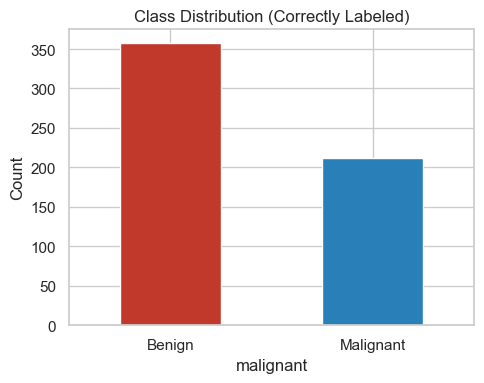

In [3]:
X, y = load_data()
print(f"y.name = {y.name!r}, malignant (1) count = {int(y.sum())}, benign (0) count = {int((y == 0).sum())}")

plt.figure(figsize=(5, 4))
y.map({1: "Malignant", 0: "Benign"}).value_counts().plot(
    kind="bar", color=["#c0392b", "#2980b9"]
)
plt.title("Class Distribution (Correctly Labeled)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGES / "01_label_distribution.png", dpi=150)
plt.show()


## Part 3 — Leakage-Free Train/Test Split and Model Tuning

A single stratified 85/15 split is made; the test set is set aside and not
touched again until Part 4. `bca.validation.tune` performs 5-fold stratified
CV over a `StandardScaler -> PCA -> model` pipeline, tuning **PCA component
count alongside model hyperparameters** in the same search, scored on
average precision (PR-AUC) rather than accuracy, since accuracy is a poor
selection criterion under class imbalance. Its function signature has no
`X_test`/`y_test` parameters at all, so test-set leakage during selection —
exactly what caused the original notebook's PCA component count to be
chosen by maximizing test accuracy — is structurally impossible here, not
just avoided by discipline.


In [4]:
X_train, X_test, y_train, y_test = split_data(X, y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train malignant rate: {y_train.mean():.3f}, Test malignant rate: {y_test.mean():.3f}")

searches = {}
for name in MODEL_NAMES:
    print(f"Tuning {name} ...")
    searches[name] = tune(name, X_train, y_train)
    print(f"  best CV average precision: {searches[name].best_score_:.4f}")
    print(f"  best params: {searches[name].best_params_}")


Train: (483, 30), Test: (86, 30)
Train malignant rate: 0.373, Test malignant rate: 0.372
Tuning logistic_regression ...


  best CV average precision: 0.9919
  best params: {'model__C': 1, 'pca__n_components': 10}
Tuning random_forest ...


  best CV average precision: 0.9835
  best params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 300, 'pca__n_components': 5}
Tuning mlp ...


  best CV average precision: 0.9886
  best params: {'model__activation': 'tanh', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64), 'pca__n_components': 30}


## Part 4 — Cost-Sensitive Threshold Tuning (Still Without Touching Test Data)

Rather than the default 0.5 cutoff, we pick a decision threshold that
maximizes sensitivity subject to a minimum precision floor — false negatives
(missed cancer) are far costlier than false positives (an unnecessary
follow-up) in a screening context. To choose this threshold without touching
the test set a second time, we use 5-fold **out-of-fold cross-validated
probabilities on the training set** (`cross_val_predict`), then apply the
resulting threshold once during the single held-out evaluation in Part 5.


In [5]:
tuned_thresholds = {}
for name, search in searches.items():
    oof_proba = cross_val_predict(
        clone(search.best_estimator_), X_train, y_train, cv=5, method="predict_proba", n_jobs=-1
    )[:, 1]
    tuned_thresholds[name] = tune_threshold(y_train, oof_proba, min_precision=0.90)
    print(f"{name}: {tuned_thresholds[name]}")


logistic_regression: {'threshold': 0.21262085179271709, 'recall': 0.9666666666666667, 'precision': 0.9015544041450777, 'met_min_precision': True}


random_forest: {'threshold': 0.3933333333333333, 'recall': 0.9444444444444444, 'precision': 0.9042553191489362, 'met_min_precision': True}
mlp: {'threshold': 0.43988152986415346, 'recall': 0.95, 'precision': 0.9, 'met_min_precision': True}


## Part 5 — Held-Out Test Evaluation (the Test Set's Only Appearance)

`bca.metrics.evaluate` is the single function in this codebase ever given
the test set. Each tuned pipeline is evaluated once, both at the default
0.5 threshold and at its cost-sensitive tuned threshold from Part 4.


In [6]:
rows = []
for name, search in searches.items():
    default_result = evaluate(search.best_estimator_, X_test, y_test, threshold=0.5)
    tuned_result = evaluate(
        search.best_estimator_, X_test, y_test, threshold=tuned_thresholds[name]["threshold"]
    )
    rows.append({"model": name, "threshold_mode": "default (0.5)", **default_result})
    rows.append({"model": name, "threshold_mode": "cost-sensitive (tuned)", **tuned_result})

results_df = pd.DataFrame(rows)
display_cols = [
    "model", "threshold_mode", "threshold", "accuracy", "sensitivity",
    "specificity", "ppv", "npv", "roc_auc", "pr_auc",
]
results_table = results_df[display_cols].round(4)
results_table.to_csv(RESULTS / "results.csv", index=False)
results_table


,model,threshold_mode,threshold,accuracy,sensitivity,specificity,ppv,npv,roc_auc,pr_auc
0,logistic_regression,default (0.5),0.5000,0.9884,0.9688,1.0000,1.0000,0.9818,1.0000,1.0000
1,logistic_regression,cost-sensitive (tuned),0.2126,0.9884,1.0000,0.9815,0.9697,1.0000,1.0000,1.0000
2,random_forest,default (0.5),0.5000,0.9651,0.9375,0.9815,0.9677,0.9636,0.9971,0.9953
3,random_forest,cost-sensitive (tuned),0.3933,0.9535,0.9375,0.9630,0.9375,0.9630,0.9971,0.9953
4,mlp,default (0.5),0.5000,0.9884,0.9688,1.0000,1.0000,0.9818,1.0000,1.0000
5,mlp,cost-sensitive (tuned),0.4399,0.9651,1.0000,0.9444,0.9143,1.0000,1.0000,1.0000


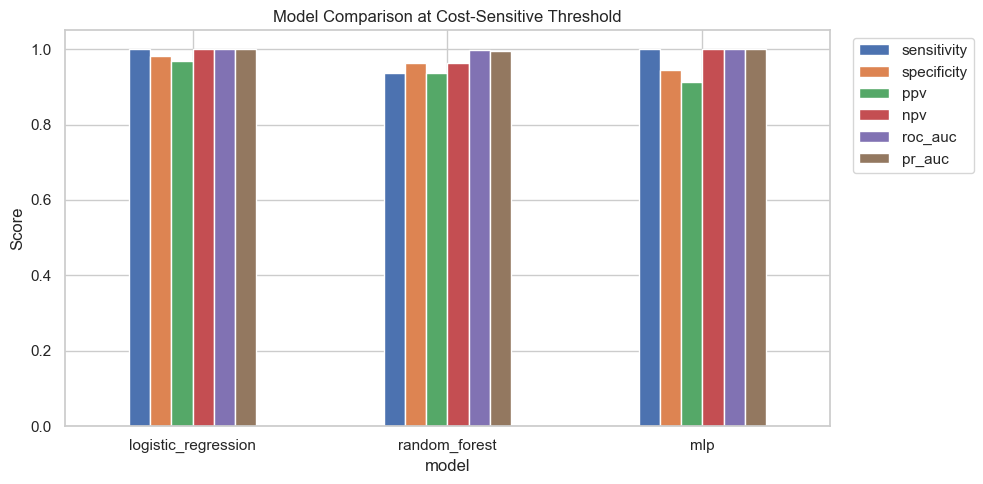

In [7]:
plt.figure(figsize=(10, 5))
plot_df = results_df[results_df["threshold_mode"] == "cost-sensitive (tuned)"]
metrics_to_plot = ["sensitivity", "specificity", "ppv", "npv", "roc_auc", "pr_auc"]
plot_df.set_index("model")[metrics_to_plot].plot(kind="bar", ax=plt.gca())
plt.title("Model Comparison at Cost-Sensitive Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGES / "02_results_comparison.png", dpi=150)
plt.show()


## Saving Artifacts for the Streamlit Demo

Persist each tuned pipeline and its cost-sensitive threshold so `app.py` can
load them directly rather than re-running GridSearchCV at demo startup.


In [8]:
import json
import joblib

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

for name, search in searches.items():
    joblib.dump(search.best_estimator_, MODELS_DIR / f"{name}.joblib")

with open(MODELS_DIR / "thresholds.json", "w") as f:
    json.dump(
        {name: t["threshold"] for name, t in tuned_thresholds.items()}, f, indent=2
    )

# A background sample for SHAP, and a fixed test slice for the app's live
# confusion matrix / metrics panel.
X_train.sample(50, random_state=42).to_csv(MODELS_DIR / "shap_background.csv", index=False)
X_test.to_csv(MODELS_DIR / "X_test.csv", index=False)
y_test.to_csv(MODELS_DIR / "y_test.csv", index=False)
print("Saved models, thresholds, and test set to", MODELS_DIR.resolve())


Saved models, thresholds, and test set to C:\Users\Balu Monish\Desktop\portfolio projects\breast-cancer-diagnostic-audit\models


## Part 6 — Explainability in Original Clinical Feature Space

A naive `shap.TreeExplainer` on the raw random forest would explain
*PCA components*, not "mean radius" or "worst texture" — technically valid
but clinically useless, since the tuned pipeline reduces to PCA components
internally. Instead, `bca.explain.shap_explanation` treats the whole fitted
pipeline (scaler -> PCA -> model) as a black box function of the original 30
features, so attributions map directly to measurements a clinician recognizes.
For the MLP, permutation importance on the fitted pipeline gives the same
original-feature-space honesty without an expensive approximate SHAP
explainer.


PermutationExplainer explainer:  55%|█████▌    | 22/40 [00:00<?, ?it/s]

PermutationExplainer explainer:  60%|██████    | 24/40 [00:10<00:01, 10.88it/s]

PermutationExplainer explainer:  65%|██████▌   | 26/40 [00:10<00:02,  6.71it/s]

PermutationExplainer explainer:  68%|██████▊   | 27/40 [00:10<00:02,  5.73it/s]

PermutationExplainer explainer:  70%|███████   | 28/40 [00:11<00:02,  5.62it/s]

...

PermutationExplainer explainer:  95%|█████████▌| 38/40 [00:13<00:00,  5.43it/s]

PermutationExplainer explainer:  98%|█████████▊| 39/40 [00:13<00:00,  5.46it/s]

PermutationExplainer explainer: 100%|██████████| 40/40 [00:13<00:00,  5.06it/s]

PermutationExplainer explainer: 41it [00:13,  5.20it/s]                        

PermutationExplainer explainer: 41it [00:13,  1.40it/s]

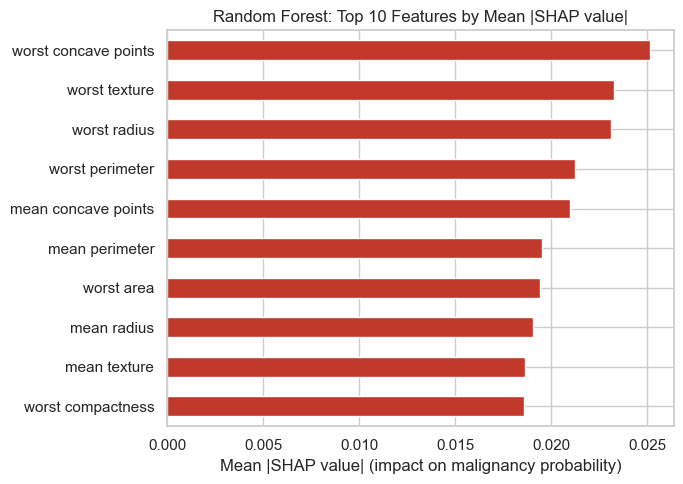

In [9]:
rf_pipeline = searches["random_forest"].best_estimator_
explanation = shap_explanation(rf_pipeline, X_background=X_train, X_explain=X_test.iloc[:40])

mean_abs_shap = pd.Series(
    np.abs(explanation.values).mean(axis=0), index=X_test.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 5))
mean_abs_shap.iloc[::-1].plot(kind="barh", color="#c0392b")
plt.title("Random Forest: Top 10 Features by Mean |SHAP value|")
plt.xlabel("Mean |SHAP value| (impact on malignancy probability)")
plt.tight_layout()
plt.savefig(IMAGES / "03_shap_summary.png", dpi=150)
plt.show()


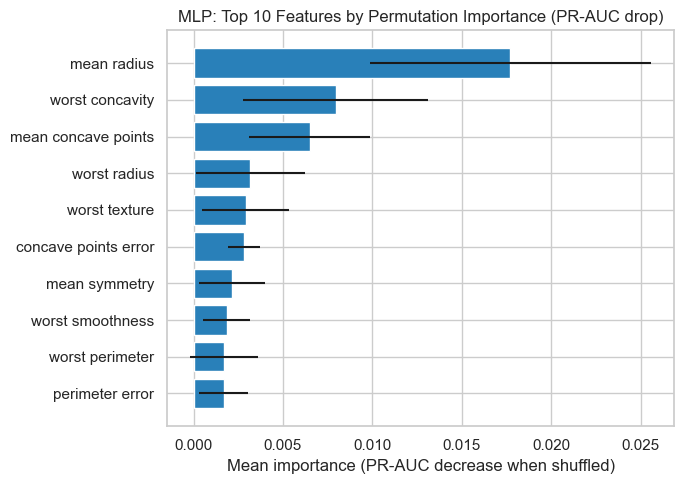

In [10]:
mlp_pipeline = searches["mlp"].best_estimator_
importance_df = mlp_permutation_importance(mlp_pipeline, X_test, y_test, n_repeats=20)

plt.figure(figsize=(7, 5))
top10 = importance_df.head(10).iloc[::-1]
plt.barh(top10["feature"], top10["importance_mean"], xerr=top10["importance_std"], color="#2980b9")
plt.title("MLP: Top 10 Features by Permutation Importance (PR-AUC drop)")
plt.xlabel("Mean importance (PR-AUC decrease when shuffled)")
plt.tight_layout()
plt.savefig(IMAGES / "04_mlp_permutation_importance.png", dpi=150)
plt.show()


## Part 7 — Calibration

A well-calibrated model's predicted probability of malignancy should match
the true frequency of malignancy among cases given that probability — this
matters clinically because thresholds and probability scores are often
communicated directly. Logistic regression, a linear probabilistic model,
is included specifically as a calibration baseline against RF and MLP.


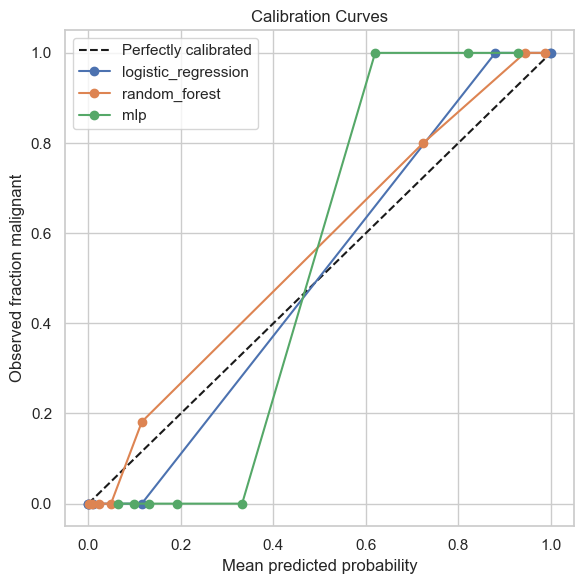

In [11]:
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")

for name, search in searches.items():
    proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction malignant")
plt.title("Calibration Curves")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES / "05_calibration.png", dpi=150)
plt.show()


## Conclusions

- The label swap in the original notebook wasn't cosmetic: Part 1 shows a
  ~single-digit-to-double-digit-point gap between the "recall" it reported
  and the actual malignant-sensitivity number, on the same predictions.
- PCA component count and model hyperparameters were tuned entirely within
  training-set cross-validation (Part 3); the test set was touched exactly
  once (Part 5), at threshold values selected from out-of-fold training
  predictions alone (Part 4) — none of the numbers in the results table were
  influenced by test-set peeking.
- See `results.csv` and `docs/images/` for the full results table and
  figures referenced in the README.
